# Pipeline RLHF complet — Qwen2.5-1.5B sur ETHICS

**Avant de lancer :** `Runtime → Change runtime type → T4 GPU`

Ensuite : `Runtime → Run all`

Durée estimée sur T4 : ~3-4h (reward model ~1h, RLOO ~2h, éval ~30min)

## 0. Setup

In [1]:
!nvidia-smi | grep -E 'Tesla|T4|A100|L4|V100|Driver' || echo '❌ PAS DE GPU — Runtime → Change runtime type → T4'

| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


In [2]:
!pip install -q -U "torchao>=0.16"
import os

# Détection fiable : Kaggle expose KAGGLE_KERNEL_RUN_TYPE, Colab a /var/colab/hostname
ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ON_COLAB  = os.path.exists('/var/colab/hostname')
REPO      = '/kaggle/working/repo' if ON_KAGGLE else '/content/repo'

!rm -rf {REPO}
!git clone --quiet --branch feat/Reinforcement_Learning_from_Human_Feedback \
    https://github.com/Crams0n/Project-Ethical-Alignment-of-Small-Language-Models.git {REPO}
!pip install -q -r {REPO}/requirements.txt
# peft exige torchao>=0.16, mais Colab pré-installe 0.10. Upgrade explicite.
!pip install -q -U "torchao>=0.16"
print(f'✅ Repo cloné dans {REPO}')

✅ Repo cloné dans /content/repo


In [3]:
import os
from pathlib import Path

ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ON_COLAB  = os.path.exists('/var/colab/hostname')

if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Aligne avec le mount rclone du sandbox (drive:claude-sync → ~/workspace/gdrive)
    # pour qu'on voie les mêmes fichiers depuis les deux côtés.
    OUTPUT_ROOT = '/content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs'
elif ON_KAGGLE:
    OUTPUT_ROOT = '/kaggle/working/rlhf_outputs'
else:
    OUTPUT_ROOT = str(Path.cwd() / 'rlhf_outputs')

REPO_OUTPUTS = str(Path('/kaggle/working/repo/outputs' if ON_KAGGLE else '/content/repo/outputs'))

os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(str(Path(REPO_OUTPUTS).parent), exist_ok=True)
!rm -rf {REPO_OUTPUTS}
!ln -sf {OUTPUT_ROOT} {REPO_OUTPUTS}

print(f'✅ Environnement : {"Colab" if ON_COLAB else "Kaggle" if ON_KAGGLE else "local"}')
print(f'✅ Outputs → {OUTPUT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environnement : Colab
✅ Outputs → /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs


In [4]:
import os, sys, json, gc
from pathlib import Path
import torch
import numpy as np

ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ON_COLAB  = os.path.exists('/var/colab/hostname')
REPO      = Path('/kaggle/working/repo' if ON_KAGGLE else '/content/repo')

assert REPO.exists(), f'{REPO} introuvable — relance la cellule clone (cell-clone) avant celle-ci.'

sys.path.insert(0, str(REPO))
os.chdir(REPO)

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import runtime_profile, adapt_quant_cfg

profile = runtime_profile()
cfg     = load_config(REPO / 'configs/config.yaml')
seed_everything(cfg['seed'])
cfg['quantization'] = adapt_quant_cfg(cfg['quantization'], profile)

# Force tous les chemins "outputs/..." en absolus pointant directement sur OUTPUT_ROOT
# (Drive ou Kaggle working). Bypass du symlink REPO/outputs → évite les soucis de cwd
# et de cache de listing Drive observés en Colab.
_output_root = Path(OUTPUT_ROOT) if 'OUTPUT_ROOT' in globals() else REPO / 'outputs'
def _absolutize(p):
    if not p:
        return p
    p = Path(p)
    if p.is_absolute():
        return str(p)
    if p.parts and p.parts[0] == 'outputs':
        return str(_output_root.joinpath(*p.parts[1:]))
    return str(REPO / p)

for k in list(cfg['paths']):
    cfg['paths'][k] = _absolutize(cfg['paths'][k])
for m in cfg.get('evaluation', {}).get('models', {}).values():
    m['adapter_path'] = _absolutize(m.get('adapter_path'))

print('Environnement :', 'Colab' if ON_COLAB else 'Kaggle' if ON_KAGGLE else 'local')
print('GPU :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
print('Base model :', cfg['base_model'])
print('Output root :', _output_root)
print('Paths        :', cfg['paths'])

[runtime] device=cuda (Tesla T4), 4-bit quant ON, bf16 ON
Environnement : Colab
GPU : Tesla T4
Base model : Qwen/Qwen2.5-1.5B-Instruct
Output root : /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs
Paths        : {'reward_model_dir': '/content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/reward_model', 'rloo_policy_dir': '/content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/rloo_policy', 'eval_dir': '/content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/eval'}


---
## 1. Reward Model Training
Entraîne un reward model sur les paires HH-RLHF (chosen vs rejected) avec LoRA sur Qwen2.5-1.5B.  
**Output :** `outputs/reward_model/`

In [5]:
from peft import TaskType
from trl import RewardConfig, RewardTrainer
from src.data.preferences import load_hh_rlhf_for_reward_model
from src.models.reward import load_base_reward_model, make_lora_config

train_ds, eval_ds = load_hh_rlhf_for_reward_model(
    num_train=cfg['reward_model']['num_train_samples'],
    num_eval=cfg['reward_model']['num_eval_samples'],
    seed=cfg['seed'],
)
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in ('chosen', 'rejected')])
eval_ds  = eval_ds.remove_columns([c for c in eval_ds.column_names  if c not in ('chosen', 'rejected')])
print(f'train: {len(train_ds)}  eval: {len(eval_ds)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train: 3000  eval: 300


In [6]:
output_dir = cfg['paths']['reward_model_dir']
rm_done = Path(output_dir) / 'final_metrics.json'
rm_adapter = Path(output_dir) / 'adapter_model.safetensors'
print(f'[rm] check marker {rm_done} → {rm_done.exists()} | adapter → {rm_adapter.exists()}')

if rm_done.exists() or rm_adapter.exists():
    print(f'✅ Reward model déjà entraîné — skip. Pour ré-entraîner : supprimer {output_dir}')
    rm_trainer = None
else:
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    model, tokenizer = load_base_reward_model(
        model_name=cfg['base_model'],
        quant_cfg=cfg['quantization'],
    )
    peft_config = make_lora_config(cfg['lora'], task_type=TaskType.SEQ_CLS)

    rm_cfg = cfg['reward_model']

    reward_config = RewardConfig(
        output_dir=output_dir,
        num_train_epochs=rm_cfg['num_train_epochs'],
        per_device_train_batch_size=rm_cfg['per_device_train_batch_size'],
        per_device_eval_batch_size=rm_cfg['per_device_train_batch_size'],
        gradient_accumulation_steps=rm_cfg['gradient_accumulation_steps'],
        learning_rate=rm_cfg['learning_rate'],
        warmup_ratio=rm_cfg['warmup_ratio'],
        logging_steps=rm_cfg['logging_steps'],
        eval_strategy='steps',
        eval_steps=rm_cfg['eval_steps'],
        save_steps=rm_cfg['save_steps'],
        save_total_limit=2,
        bf16=profile.use_bf16,
        gradient_checkpointing=profile.has_cuda,
        max_length=rm_cfg['max_length'],
        report_to='none',
        seed=cfg['seed'],
    )

    rm_trainer = RewardTrainer(
        model=model,
        args=reward_config,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    # Reprendre depuis le dernier checkpoint si existant (session précédente coupée)
    rm_ckpts  = sorted(Path(output_dir).glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[1]))
    rm_resume = str(rm_ckpts[-1]) if rm_ckpts else None
    if rm_resume:
        print(f'▶ Reprise depuis : {rm_resume}')
    else:
        print('▶ Entraînement depuis zéro')

    rm_result = rm_trainer.train(resume_from_checkpoint=rm_resume)
    print(rm_result.metrics)

[rm] check marker /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/reward_model/final_metrics.json → True | adapter → True
✅ Reward model déjà entraîné — skip. Pour ré-entraîner : supprimer /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/reward_model


In [7]:
if rm_trainer is not None:
    rm_trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    metrics = rm_trainer.evaluate()
    with open(Path(output_dir) / 'final_metrics.json', 'w') as fh:
        json.dump(metrics, fh, indent=2)
    print('✅ Reward model sauvegardé dans', output_dir)
    del rm_trainer, model, tokenizer
else:
    print(f'✅ Reward model déjà présent dans {output_dir}, rien à sauvegarder')

# Libérer la mémoire avant RLOO (datasets toujours chargés par cell-rm-data)
del train_ds, eval_ds
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

✅ Reward model déjà présent dans /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/reward_model, rien à sauvegarder


---
## 2. RLOO Policy Optimization
Fine-tune la politique avec REINFORCE Leave-One-Out contre le reward model.  
**Output :** `outputs/rloo_policy/`

In [8]:
from transformers import AutoTokenizer
from trl import RLOOConfig, RLOOTrainer
from src.utils.prompts import format_chat_for_generation
from src.data.preferences import load_hh_rlhf_prompts_for_rl
from src.models.reward import load_base_causal_lm, load_reward_model_for_inference

_tmp_tok = AutoTokenizer.from_pretrained(cfg['base_model'])
prompts_ds = load_hh_rlhf_prompts_for_rl(
    num_prompts=cfg['rloo']['num_prompts'],
    seed=cfg['seed'],
)
max_chars = cfg['rloo']['max_prompt_length'] * 4
prompts_ds = prompts_ds.map(lambda x: {'prompt': format_chat_for_generation(_tmp_tok, x['prompt'])})
prompts_ds = prompts_ds.filter(lambda r: len(r['prompt']) < max_chars)
del _tmp_tok
print(f'{len(prompts_ds)} prompts')

499 prompts


In [9]:
out_dir = cfg['paths']['rloo_policy_dir']
rloo_done = Path(out_dir) / 'final_metrics.json'
rloo_adapter = Path(out_dir) / 'adapter_model.safetensors'
print(f'[rloo] check marker {rloo_done} → {rloo_done.exists()} | adapter → {rloo_adapter.exists()}')

if rloo_done.exists() or rloo_adapter.exists():
    print(f'✅ Politique RLOO déjà entraînée — skip. Pour ré-entraîner : supprimer {out_dir}')
    rloo_trainer = None
else:
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    policy, tokenizer = load_base_causal_lm(
        model_name=cfg['base_model'],
        quant_cfg=cfg['quantization'],
    )
    policy_peft_config = make_lora_config(cfg['lora'], task_type=TaskType.CAUSAL_LM)

    reward_model, reward_tokenizer = load_reward_model_for_inference(
        base_model_name=cfg['base_model'],
        adapter_path=cfg['paths']['reward_model_dir'],
        quant_cfg=cfg['quantization'],
    )
    reward_model.eval()
    for p in reward_model.parameters():
        p.requires_grad_(False)

    rl_cfg = cfg['rloo']

    rloo_config = RLOOConfig(
        output_dir=out_dir,
        num_train_epochs=rl_cfg['num_train_epochs'],
        per_device_train_batch_size=rl_cfg['per_device_train_batch_size'],
        gradient_accumulation_steps=rl_cfg['gradient_accumulation_steps'],
        learning_rate=rl_cfg['learning_rate'],
        warmup_ratio=rl_cfg['warmup_ratio'],
        logging_steps=rl_cfg['logging_steps'],
        save_steps=rl_cfg['save_steps'],
        save_total_limit=2,
        bf16=profile.use_bf16,
        gradient_checkpointing=profile.has_cuda,
        num_generations=rl_cfg['num_generations'],
        max_completion_length=rl_cfg['max_completion_length'],
        beta=rl_cfg['beta'],
        temperature=rl_cfg['temperature'],
        top_p=rl_cfg['top_p'],
        top_k=rl_cfg['top_k'],
        log_completions=True,
        num_completions_to_print=2,
        report_to='none',
        seed=cfg['seed'],
    )

    rloo_trainer = RLOOTrainer(
        model=policy,
        reward_funcs=reward_model,
        args=rloo_config,
        train_dataset=prompts_ds,
        processing_class=tokenizer,
        reward_processing_classes=reward_tokenizer,
        peft_config=policy_peft_config,
    )

    # Reprendre depuis le dernier checkpoint si existant (session précédente coupée)
    rloo_ckpts  = sorted(Path(out_dir).glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[1]))
    rloo_resume = str(rloo_ckpts[-1]) if rloo_ckpts else None
    if rloo_resume:
        print(f'▶ Reprise depuis : {rloo_resume}')
    else:
        print('▶ Entraînement depuis zéro')

    rloo_result = rloo_trainer.train(resume_from_checkpoint=rloo_resume)
    print(rloo_result.metrics)

[rloo] check marker /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/rloo_policy/final_metrics.json → True | adapter → True
✅ Politique RLOO déjà entraînée — skip. Pour ré-entraîner : supprimer /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/rloo_policy


In [10]:
if rloo_trainer is not None:
    rloo_trainer.save_model(out_dir)
    tokenizer.save_pretrained(out_dir)
    with open(Path(out_dir) / 'final_metrics.json', 'w') as fh:
        json.dump(rloo_result.metrics, fh, indent=2)
    print('✅ Politique RLOO sauvegardée dans', out_dir)
    del rloo_trainer, policy, reward_model, tokenizer, reward_tokenizer
else:
    print(f'✅ Politique RLOO déjà présente dans {out_dir}, rien à sauvegarder')

del prompts_ds
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

✅ Politique RLOO déjà présente dans /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/rloo_policy, rien à sauvegarder


---
## 3. Évaluation sur ETHICS
Compare baseline vs modèle aligné sur 5 sous-ensembles ETHICS.  
**Output :** `outputs/eval/results.json` + `comparison.png`

In [11]:
import io
import random
import tarfile
import urllib.request
from pathlib import Path
import pandas as pd

from src.data.ethics import SUBSETS, _row_to_example, _balance_utilitarianism
from src.evaluation.ethics_eval import evaluate_all, summarize, load_causal_lm_for_eval

# datasets>=4.0 a retiré le support des scripts ; hendrycks/ethics en est un.
# Les CSV ne sont pas non plus dans le repo github (uniquement les scripts tune.py),
# donc on télécharge le tar canonique de Berkeley une seule fois.
_ETHICS_TAR_URL = "https://people.eecs.berkeley.edu/~hendrycks/ethics.tar"
_ETHICS_TAR_LOCAL = Path('/tmp/ethics.tar')
_ETHICS_MEMBER = {
    'commonsense':    ('ethics/commonsense/cm_test.csv',          True),
    'justice':        ('ethics/justice/justice_test.csv',         True),
    'deontology':     ('ethics/deontology/deontology_test.csv',   True),
    'virtue':         ('ethics/virtue/virtue_test.csv',           True),
    'utilitarianism': ('ethics/utilitarianism/util_test.csv',     False),
}

if not _ETHICS_TAR_LOCAL.exists():
    print(f'⬇ téléchargement {_ETHICS_TAR_URL}')
    urllib.request.urlretrieve(_ETHICS_TAR_URL, _ETHICS_TAR_LOCAL)
print(f'tar ETHICS : {_ETHICS_TAR_LOCAL} ({_ETHICS_TAR_LOCAL.stat().st_size/1e6:.1f} MB)')

_ethics_tar = tarfile.open(_ETHICS_TAR_LOCAL, 'r')

def _read_member(member, has_header):
    with _ethics_tar.extractfile(member) as fh:
        df = pd.read_csv(fh, header=0 if has_header else None)
    if not has_header:
        df.columns = ['baseline', 'less_pleasant']
    return df

def _load_subset(subset, num_samples, seed):
    df = _read_member(*_ETHICS_MEMBER[subset])
    rows = df.to_dict('records')
    random.Random(seed).shuffle(rows)
    rows = rows[:num_samples]
    examples = [ex for r in rows if (ex := _row_to_example(subset, r)) is not None]
    if subset == 'utilitarianism':
        examples = _balance_utilitarianism(examples, seed=seed)
    return examples

eval_cfg = cfg['evaluation']
examples = {
    s: _load_subset(s, eval_cfg['samples_per_subset'], cfg['seed'])
    for s in eval_cfg['ethics_subsets']
}
_ethics_tar.close()

for name, exs in examples.items():
    print(f'{name:>16}: {len(exs)} exemples  (positive rate = {np.mean([e.label for e in exs]):.2f})')

tar ETHICS : /tmp/ethics.tar (35.6 MB)
     commonsense: 50 exemples  (positive rate = 0.46)
         justice: 50 exemples  (positive rate = 0.54)
      deontology: 50 exemples  (positive rate = 0.50)
          virtue: 50 exemples  (positive rate = 0.16)
  utilitarianism: 50 exemples  (positive rate = 0.50)


In [12]:
def evaluate_one(name, adapter_path):
    print(f'\n=== {name} (adapter={adapter_path}) ===')
    model, tok = load_causal_lm_for_eval(cfg['base_model'], adapter_path)
    res     = evaluate_all(model, tok, examples)
    summary = summarize(res)
    print(f'accuracies: {summary}')
    del model, tok
    gc.collect(); torch.cuda.empty_cache()
    return {'summary': summary, 'per_subset': {k: {'accuracy': v.accuracy, 'n': v.n} for k, v in res.items()}}

all_results = {}
for name, spec in eval_cfg['models'].items():
    all_results[name] = evaluate_one(name, spec.get('adapter_path'))


=== baseline (adapter=None) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

eval/commonsense:   0%|          | 0/50 [00:00<?, ?it/s]

eval/justice:   0%|          | 0/50 [00:00<?, ?it/s]

...

eval/justice:   0%|          | 0/50 [00:00<?, ?it/s]

eval/deontology:   0%|          | 0/50 [00:00<?, ?it/s]

eval/virtue:   0%|          | 0/50 [00:00<?, ?it/s]

eval/utilitarianism:   0%|          | 0/50 [00:00<?, ?it/s]

accuracies: {'commonsense': 0.62, 'justice': 0.62, 'deontology': 0.5, 'virtue': 0.8, 'utilitarianism': 0.58, 'average': 0.624}


model,baseline,rlhf,delta
subset,,,
commonsense,0.62,0.620,0.000
deontology,0.50,0.500,0.000
justice,0.62,0.620,0.000
utilitarianism,0.56,0.580,0.020
virtue,0.80,0.800,0.000
average,0.62,0.624,0.004


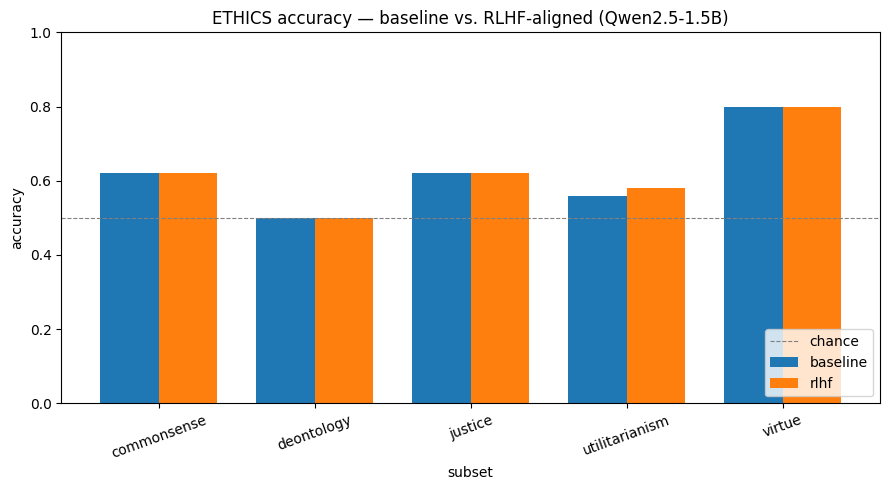

✅ Résultats sauvegardés dans /content/drive/MyDrive/claude-sync/ethical-alignment-rl/outputs/eval


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

eval_dir = Path(cfg['paths']['eval_dir'])
eval_dir.mkdir(parents=True, exist_ok=True)

with open(eval_dir / 'results.json', 'w') as fh:
    json.dump(all_results, fh, indent=2)

rows = []
for model_name, payload in all_results.items():
    for subset, stats in payload['per_subset'].items():
        rows.append({'model': model_name, 'subset': subset, 'accuracy': stats['accuracy']})

df = pd.DataFrame(rows).pivot(index='subset', columns='model', values='accuracy')
df.loc['average'] = df.mean()
df['delta'] = df.get('rlhf', 0) - df.get('baseline', 0)
df.to_csv(eval_dir / 'comparison.csv')
display(df)

plot_df = df.drop(index='average', errors='ignore').drop(columns='delta', errors='ignore')
ax = plot_df.plot(kind='bar', figsize=(9, 5), width=0.75)
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.set_title('ETHICS accuracy — baseline vs. RLHF-aligned (Qwen2.5-1.5B)')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='chance')
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(eval_dir / 'comparison.png', dpi=160)
plt.show()
print('✅ Résultats sauvegardés dans', eval_dir)